In [1]:
%cd /content
!rm -rf mccain-internship
!git clone https://github.com/PushkargithubCSE/mccain-internship.git
%cd mccain-internship/week-3/potato-finetuning
PROJECT_PATH = "/content/mccain-internship/week-3/potato-finetuning"

!pip install -q transformers roboflow python-dotenv huggingface_hub pycocotools

/content
Cloning into 'mccain-internship'...
remote: Enumerating objects: 566, done.
remote: Counting objects: 100% (566/566), done.
remote: Compressing objects: 100% (413/413), done.
remote: Total 566 (delta 147), reused 508 (delta 95), pack-reused 0 (from 0)
Receiving objects: 100% (566/566), 24.27 MiB | 19.84 MiB/s, done.
Resolving deltas: 100% (147/147), done.
/content/mccain-internship/week-3/potato-finetuning


In [3]:
import os
from dotenv import load_dotenv
from roboflow import Roboflow

load_dotenv(f"{PROJECT_PATH}/.env")
api_key = os.getenv("ROBOFLOW_API_KEY")
if not api_key:
    raise RuntimeError("ROBOFLOW_API_KEY is missing from the project .env file")

rf = Roboflow(api_key=api_key)
project = rf.workspace("pushkar-chandra").project("segmentation-jajrd")
dataset = project.version(2).download("coco-segmentation")
print(f"Dataset ready at: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Segmentation-2 in coco-segmentation:: 100%|██████████| 20/20 [00:00<00:00, 4867.19it/s]

✓ Dataset ready at: /content/mccain-internship/week-3/potato-finetuning/Segmentation-2


In [7]:
import os
from transformers import Sam3Model, Sam3Processor
from huggingface_hub import login

hf_token = os.getenv("HUGGINGFACE_TOKEN")
if not hf_token:
    raise RuntimeError("HUGGINGFACE_TOKEN is missing from the project .env file")

login(token=hf_token)

REPO_ID = "pushkar0002/finetune"

model = Sam3Model.from_pretrained(REPO_ID)
processor = Sam3Processor.from_pretrained(REPO_ID)
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()
print("Fine-tuned SAM-3 loaded from Hugging Face")

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

✓ Fine-tuned SAM-3 loaded from Hugging Face


In [8]:
import json
import numpy as np
from PIL import Image
from pycocotools import mask as coco_mask
from torch.utils.data import Dataset

class SAM3SegDataset(Dataset):
    def __init__(self, coco_json_path, images_dir):
        with open(coco_json_path) as f:
            self.coco = json.load(f)
        self.images_dir = images_dir
        self.img_id_to_info = {img['id']: img for img in self.coco['images']}
        self.annotations = self.coco['annotations']

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        ann = self.annotations[idx]
        img_info = self.img_id_to_info[ann['image_id']]
        img_path = f"{self.images_dir}/{img_info['file_name']}"
        image = Image.open(img_path).convert("RGB")

        h, w = img_info['height'], img_info['width']
        seg = ann['segmentation']

        if isinstance(seg, dict):
            rle = coco_mask.frPyObjects(seg, h, w) if isinstance(seg['counts'], list) else seg
            binary_mask = coco_mask.decode(rle)
        else:
            rles = coco_mask.frPyObjects(seg, h, w)
            rle = coco_mask.merge(rles) if isinstance(rles, list) else rles
            binary_mask = coco_mask.decode(rle)

        if binary_mask.ndim == 3:
            binary_mask = binary_mask.any(axis=2).astype(np.uint8)

        return image, torch.from_numpy(binary_mask).float(), img_info['file_name']

test_ds = SAM3SegDataset(
    f"{dataset.location}/test/_annotations.coco.json",
    f"{dataset.location}/test"
)
print(f"✓ Test dataset: {len(test_ds)} samples")

✓ Test dataset: 2 samples


In [9]:
import torch.nn.functional as F

def compute_iou_dice(pred_mask, gt_mask, threshold=0.5):
    pred_binary = (torch.sigmoid(pred_mask) > threshold).float()
    intersection = (pred_binary * gt_mask).sum()
    union = pred_binary.sum() + gt_mask.sum() - intersection
    iou = (intersection / union).item() if union > 0 else 0.0
    dice = (2 * intersection / (pred_binary.sum() + gt_mask.sum())).item() if (pred_binary.sum() + gt_mask.sum()) > 0 else 0.0
    return iou, dice

results = []

with torch.no_grad():
    for image, gt_mask, filename in test_ds:
        inputs = processor(images=image, text="damage", return_tensors="pt").to(device)
        outputs = model(**inputs)

        scores = outputs.pred_logits[0]
        best_idx = scores.argmax()
        pred_mask = outputs.pred_masks[0, best_idx].unsqueeze(0).unsqueeze(0)

        pred_mask_resized = F.interpolate(pred_mask, size=gt_mask.shape[-2:], mode="bilinear")

        iou, dice = compute_iou_dice(pred_mask_resized.squeeze(), gt_mask.to(device))

        results.append({"filename": filename, "iou": iou, "dice": dice})
        print(f"{filename}: IoU={iou:.4f}, Dice={dice:.4f}")

avg_iou = sum(r['iou'] for r in results) / len(results)
avg_dice = sum(r['dice'] for r in results) / len(results)
print(f"\n{'='*40}")
print(f"Average IoU:  {avg_iou:.4f}")
print(f"Average Dice: {avg_dice:.4f}")

damage11_png.rf.cee04fea1553265e4f196e42b08e9857.jpg: IoU=0.7853, Dice=0.8797
damage1_png.rf.81946d79fdedd5a38a48f9ba0cf62afc.jpg: IoU=0.5094, Dice=0.6750

Average IoU:  0.6473
Average Dice: 0.7773


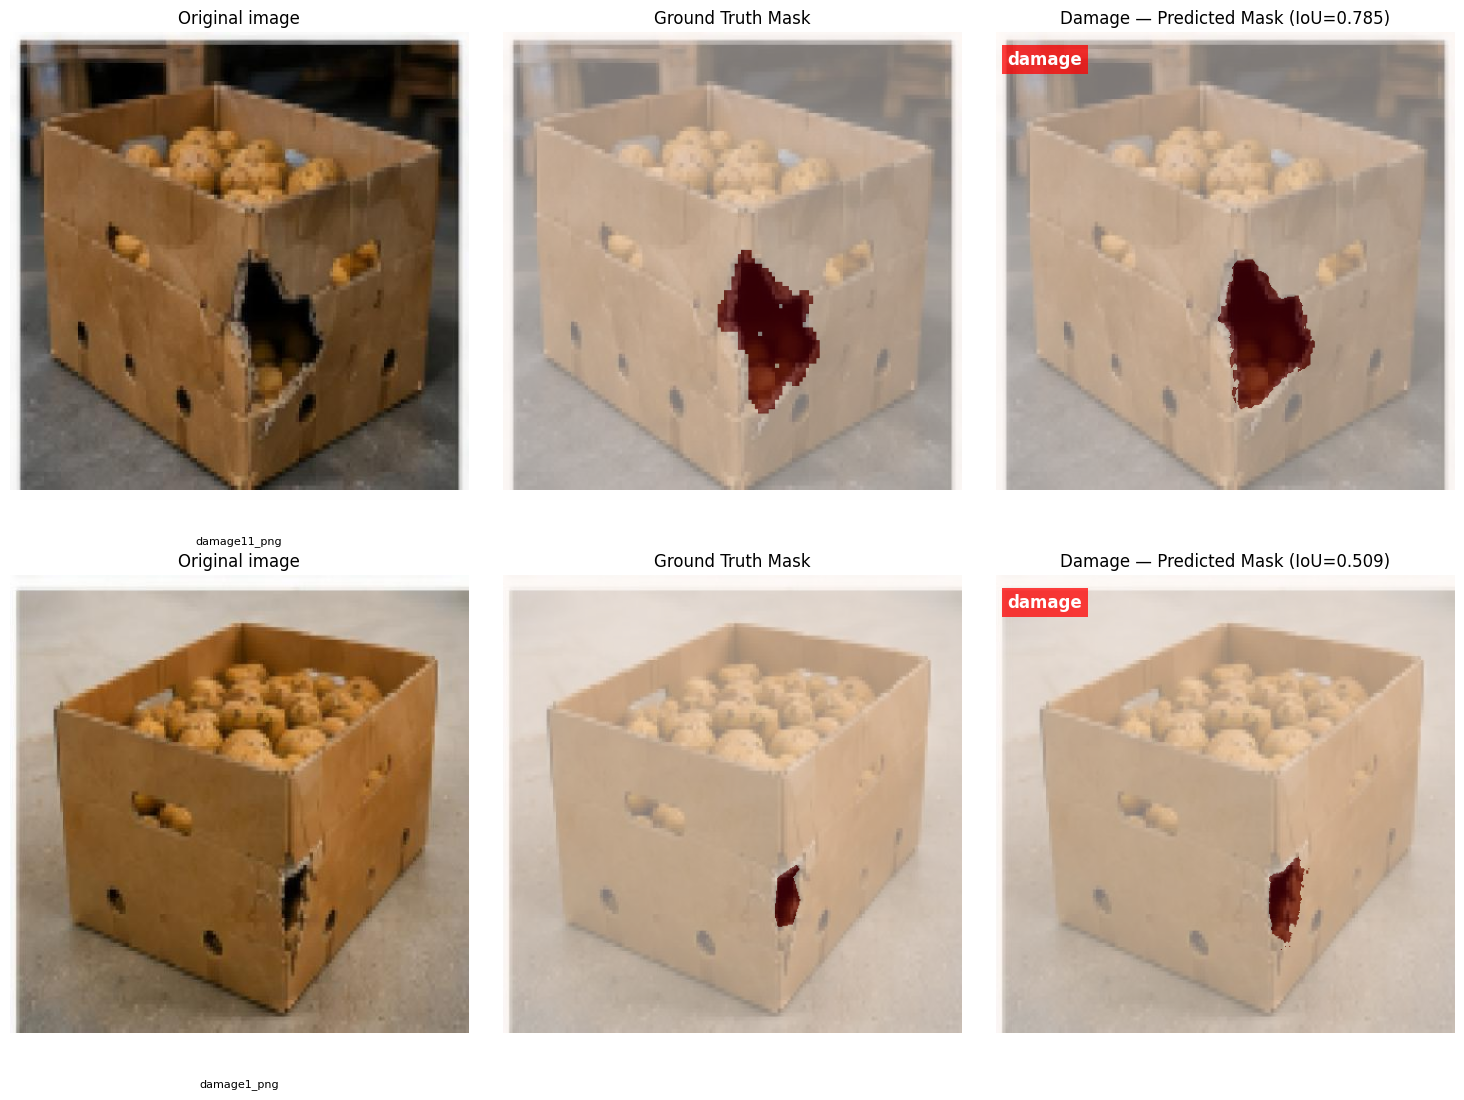

✓ Saved evaluation visualization


In [20]:
import matplotlib.pyplot as plt
import os
fig, axes = plt.subplots(len(test_ds), 3, figsize=(15, 5.5*len(test_ds)))
if len(test_ds) == 1:
    axes = axes.reshape(1, -1)

with torch.no_grad():
    for idx, (image, gt_mask, filename) in enumerate(test_ds):
        inputs = processor(images=image, text="damage", return_tensors="pt").to(device)
        outputs = model(**inputs)

        scores = outputs.pred_logits[0]
        best_idx = scores.argmax()
        pred_mask = outputs.pred_masks[0, best_idx].unsqueeze(0).unsqueeze(0)
        pred_mask_resized = F.interpolate(pred_mask, size=gt_mask.shape[-2:], mode="bilinear")
        pred_binary = (torch.sigmoid(pred_mask_resized.squeeze()) > 0.5).cpu().numpy()

        axes[idx, 0].imshow(image)
        axes[idx, 0].set_title("Original image")
        axes[idx, 0].text(0.5, -0.10, filename.split(".rf.")[0],transform=axes[idx, 0].transAxes,ha="center", va="top", fontsize=8)        
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(image)
        axes[idx, 1].imshow(gt_mask.numpy(), alpha=0.5, cmap='Reds')
        axes[idx, 1].set_title("Ground Truth Mask")
        axes[idx, 1].axis('off')

        axes[idx, 2].imshow(image)
        axes[idx, 2].imshow(pred_binary, alpha=0.5, cmap='Reds')
        axes[idx, 2].set_title(f"Damage — Predicted Mask (IoU={results[idx]['iou']:.3f})")
        axes[idx, 2].text(10, 30, "damage",color="white",fontsize=12,fontweight="bold",bbox=dict(facecolor="red", alpha=0.75, edgecolor="none", pad=4))      
        axes[idx, 2].axis('off')

import os

save_path = f"{PROJECT_PATH}/sam-3/data/test_evaluation.png"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.tight_layout(pad=2.0, w_pad=2.5, h_pad=3.0)
plt.savefig(save_path, dpi=100, bbox_inches="tight")
plt.show()
print("✓ Saved evaluation visualization")